<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-09-04 09:22:53--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  3.68MB/s    in 41s     
2026-09-04 09:23:37 (4.95 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [7]:
!pip install matplotlib

In [17]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt  # Fixed the spelling and underscore here

conn = sqlite3.connect('survey-results-public.sqlite')



## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [14]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [15]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [16]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


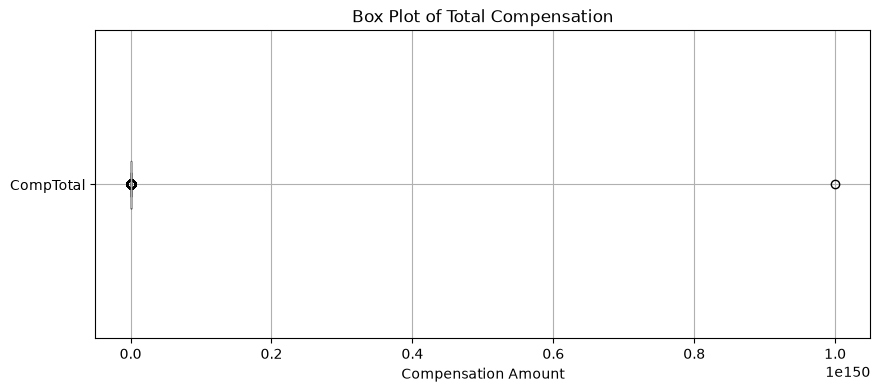

In [18]:
# your code goes here
import pandas as pd
import matplotlib.pyplot as plt

# Fetch the data from the database
query = "SELECT CompTotal FROM main"
df_comp = pd.read_sql_query(query, conn)

# Create the box plot
plt.figure(figsize=(10, 4))
df_comp.boxplot(column=['CompTotal'], vert=False)
plt.title('Box Plot of Total Compensation')
plt.xlabel('Compensation Amount')
plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


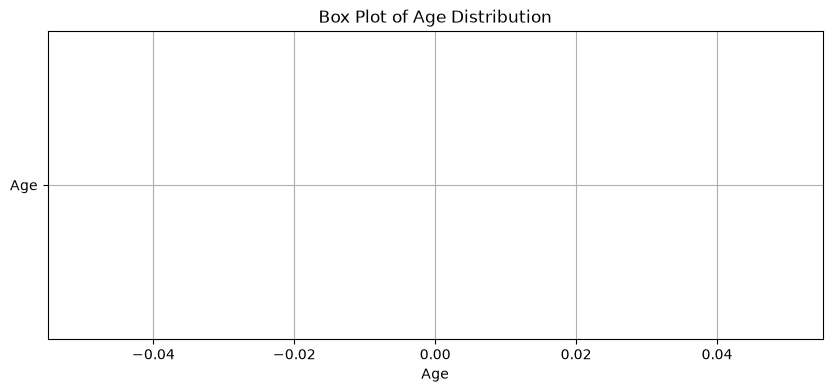

In [19]:
# your code goes here
query = "SELECT Age FROM main"
df_age = pd.read_sql_query(query, conn)

# Convert Age column to numeric values, ignoring strings that cannot convert
df_age['Age'] = pd.to_numeric(df_age['Age'], errors='coerce')

# Drop missing values for the plot
df_age = df_age.dropna()

plt.figure(figsize=(10, 4))
df_age.boxplot(column=['Age'], vert=False)
plt.title('Box Plot of Age Distribution')
plt.xlabel('Age')
plt.show()


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


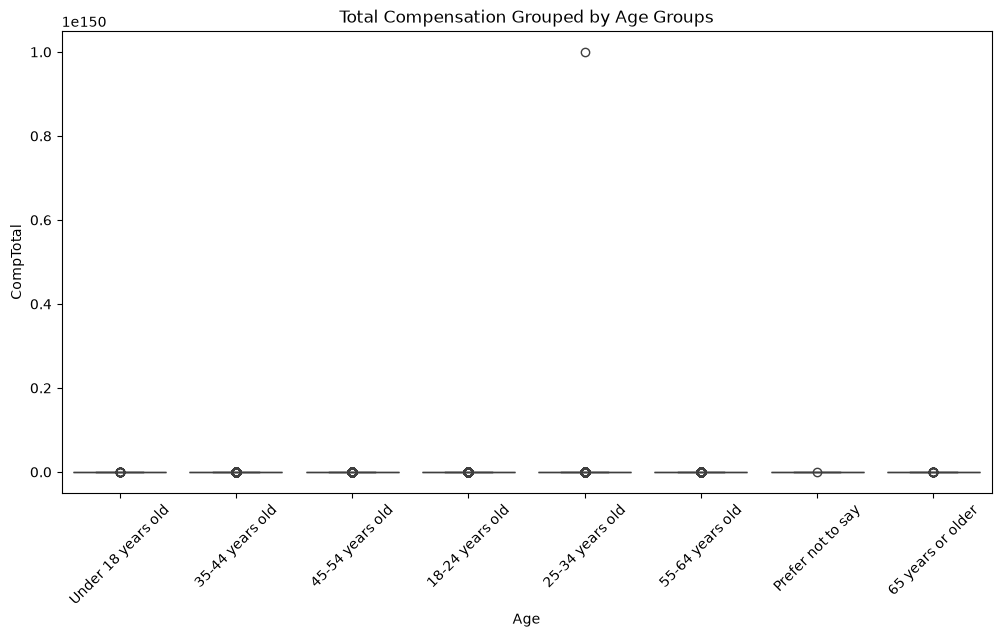

In [20]:
# your code goes here
import seaborn as sns

query = "SELECT CompTotal, Age FROM main"
df_group_age = pd.read_sql_query(query, conn)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Age', y='CompTotal', data=df_group_age)
plt.title('Total Compensation Grouped by Age Groups')
plt.xticks(rotation=45)
plt.show()


**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


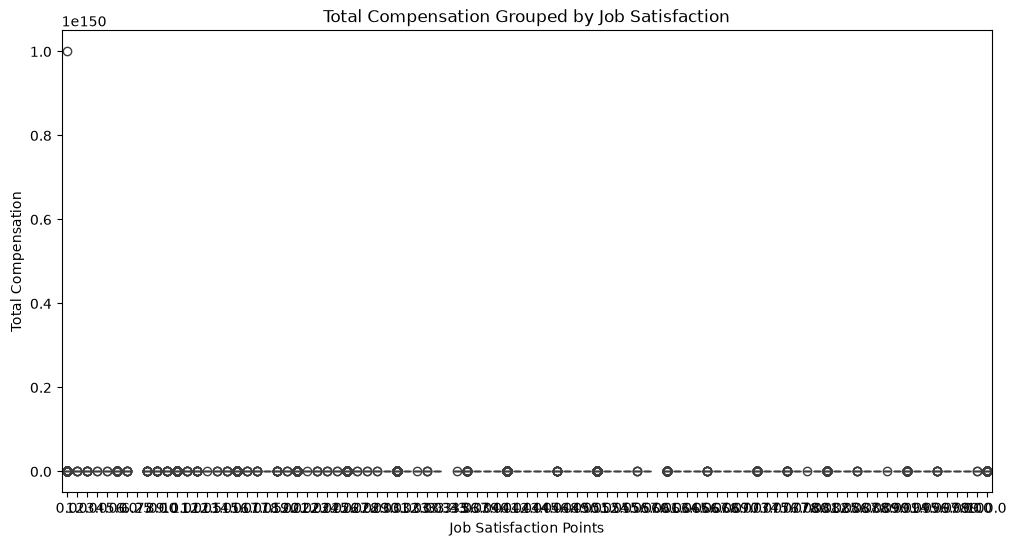

In [21]:
# your code goes here
query = "SELECT CompTotal, JobSatPoints_6 FROM main"
df_jobsat = pd.read_sql_query(query, conn)

plt.figure(figsize=(12, 6))
sns.boxplot(x='JobSatPoints_6', y='CompTotal', data=df_jobsat)
plt.title('Total Compensation Grouped by Job Satisfaction')
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Total Compensation')
plt.show()


### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


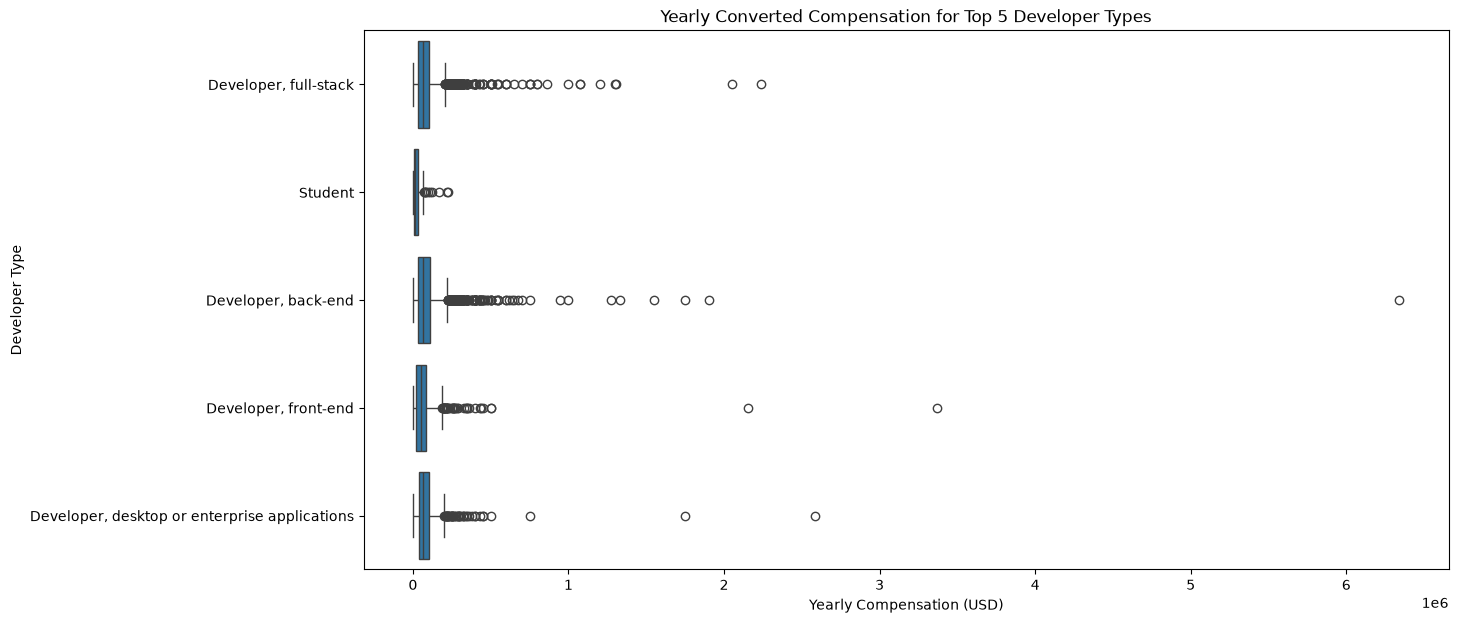

In [23]:


# Fetch Country and Total Compensation fields
# Query both columns
query = "SELECT ConvertedCompYearly, DevType FROM main"
df_dev = pd.read_sql_query(query, conn)

# Find the top 5 most common developer types
top_5_devs = df_dev['DevType'].value_counts().head(5).index

# Filter the dataframe to only include those top 5 developer types
df_top_5 = df_dev[df_dev['DevType'].isin(top_5_devs)]

plt.figure(figsize=(14, 7))
sns.boxplot(y='DevType', x='ConvertedCompYearly', data=df_top_5, orient='h')
plt.title('Yearly Converted Compensation for Top 5 Developer Types')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Developer Type')
plt.show()


**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


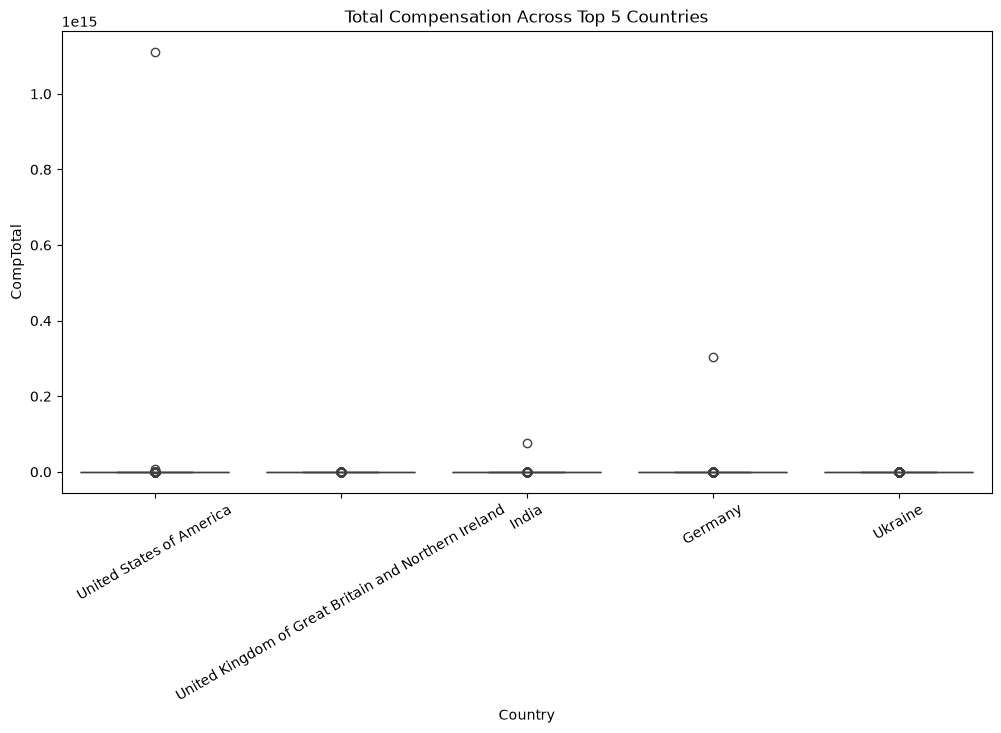

In [24]:
# your code goes here
import seaborn as sns
import matplotlib.pyplot as plt

# Fetch Country and Total Compensation fields
query = "SELECT CompTotal, Country FROM main"
df_country = pd.read_sql_query(query, conn)

# Identify the top 5 countries by respondent count
top_5_countries = df_country['Country'].value_counts().head(5).index

# Filter for only those top 5 countries
df_top_countries = df_country[df_country['Country'].isin(top_5_countries)]

# Plot the grouped box plots
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='CompTotal', data=df_top_countries)
plt.title('Total Compensation Across Top 5 Countries')
plt.xticks(rotation=30)
plt.show()


### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


/tmp/ipykernel_392/30787731.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

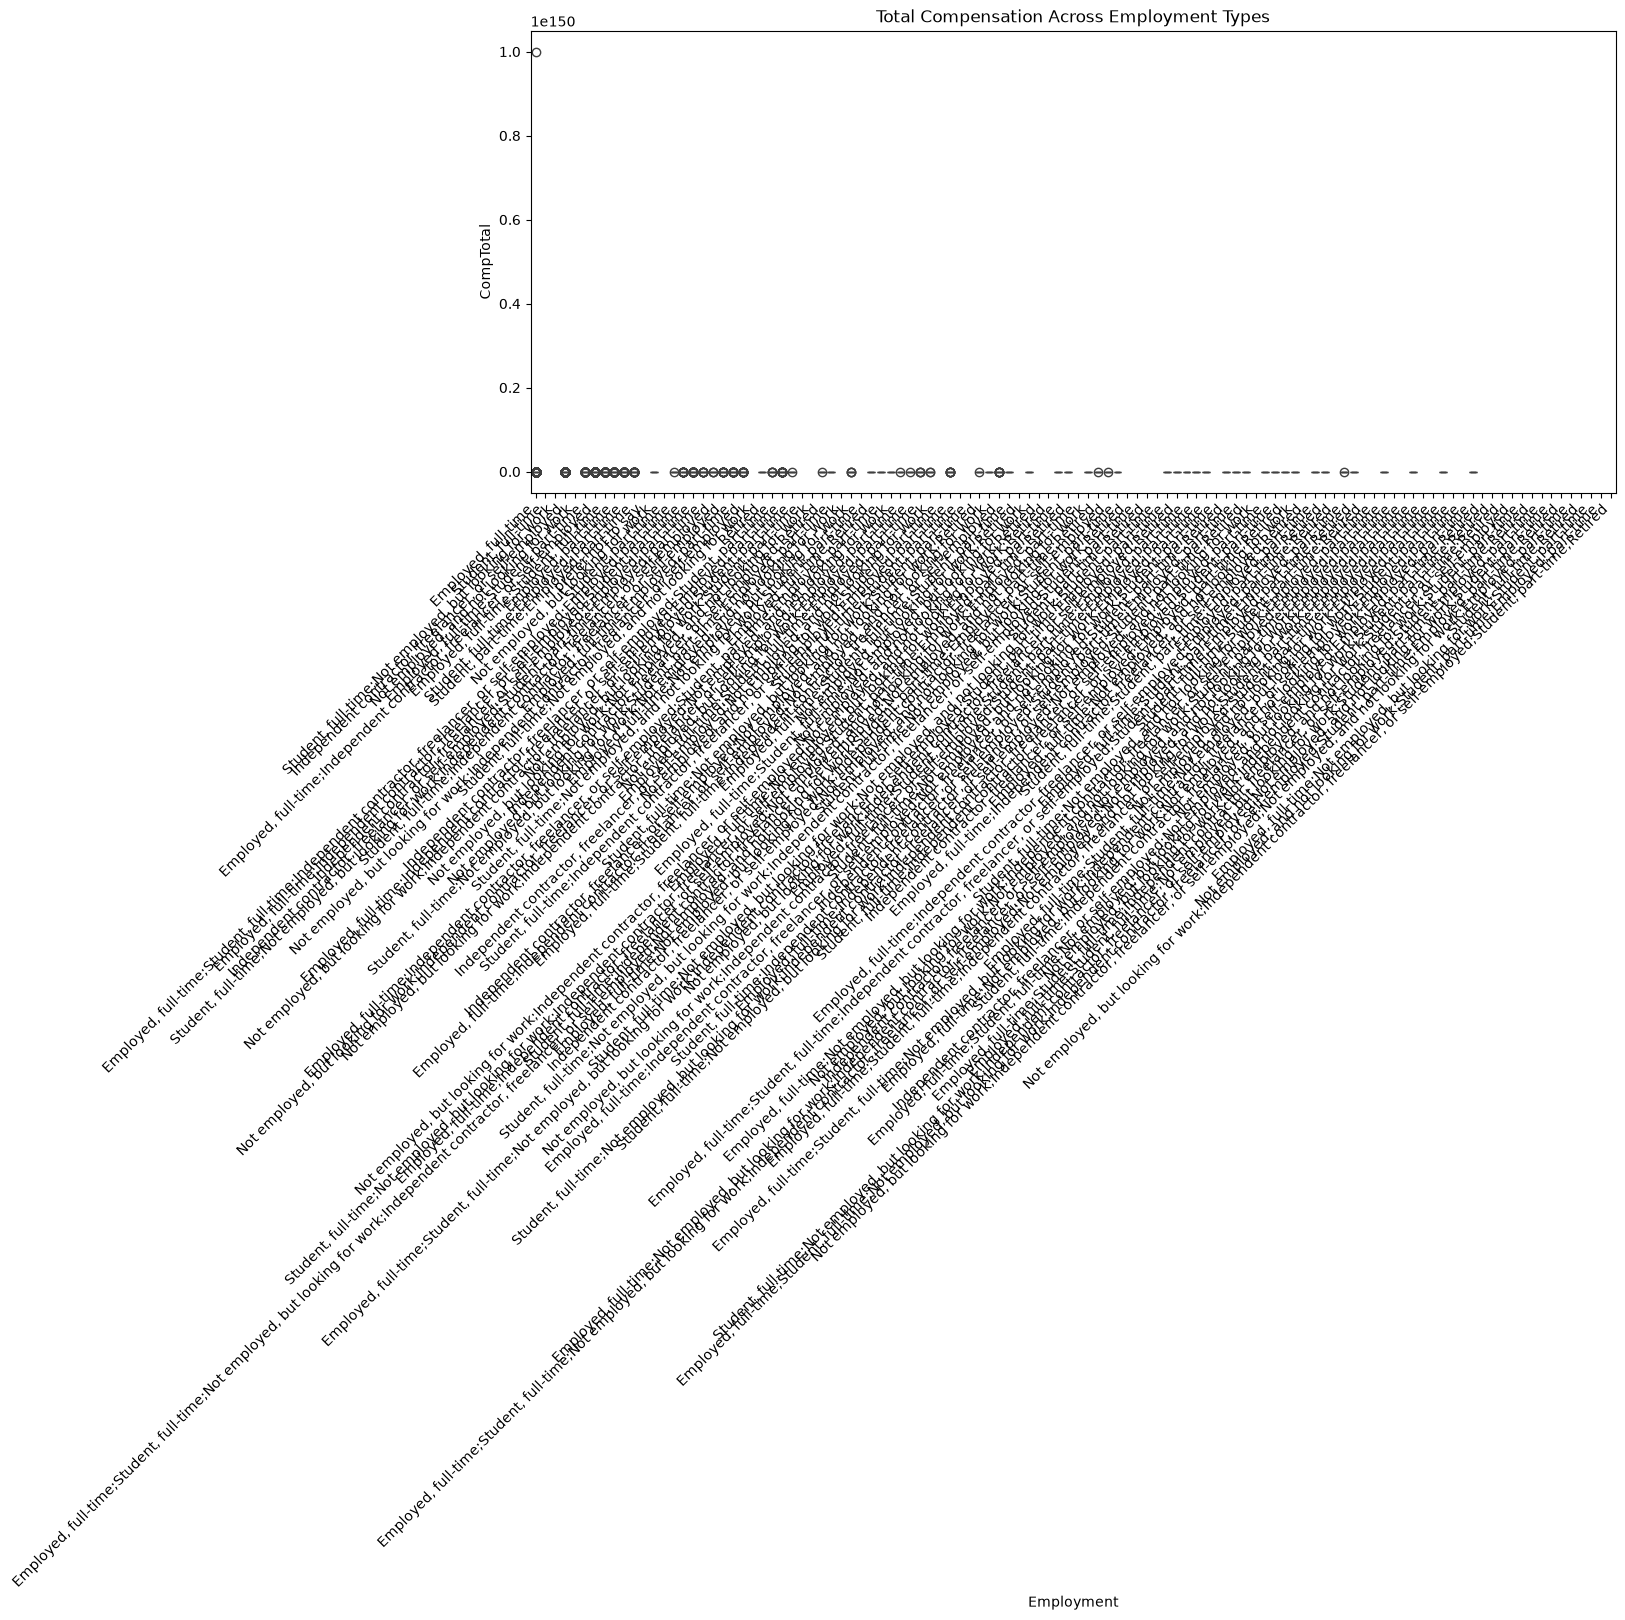

In [25]:
# your code goes here
# Fetch Employment and Total Compensation fields
query = "SELECT CompTotal, Employment FROM main"
df_employment = pd.read_sql_query(query, conn)

# Plot the grouped box plots
plt.figure(figsize=(14, 6))
sns.boxplot(x='Employment', y='CompTotal', data=df_employment)
plt.title('Total Compensation Across Employment Types')
plt.xticks(rotation=45, ha='right')  # Rotates labels so they do not overlap
plt.tight_layout()
plt.show()


**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [27]:
print(df.columns.tolist())


['COUNT(*)']

In [28]:
df.head()

,COUNT(*)
0,65437


In [30]:
plt.figure(figsize=(10, 6))
# Using JobSatPoints_6 as requested by your notebook prompt
sns.boxplot(x='JobSatPoints_6', y='YearsCodePro', data=df) 
plt.title('Distribution of Professional Coding Years by Job Satisfaction')
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Years of Professional Coding')
plt.show()



### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [30]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
